# Experiment 03 - Hopf bifurcation

Paper section reproduced: Section 4, Theorem 4.2 and Theorem 4.3.

We use `lambda` as the maximum growth parameter in `f1(S, lambda)=lambda*S/(b1+S)`. The notebook first tracks eigenvalues around the boundary equilibrium `P2`, then builds a numerical bifurcation diagram by plotting long-run maxima and minima of `x(t)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

def monod(u, a, b):
    return a * u / (b + u)

def monod_prime(u, a, b):
    return a * b / (b + u)**2

def monod_inv(D, a, b):
    return b * D / (a - D)

base = dict(b1=0.4, a2=1.0, b2=0.2, a3=0.8, b3=0.4, D1=0.1, D2=0.5, D3=0.7)

def params(lam):
    p = dict(base)
    p["a1"] = lam
    return p

def rhs(t, U, p):
    S, x, y, z = U
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    return [1 - S - f1*x, x*(f1-p["D1"]) - f2*y, y*(f2-p["D2"]) - f3*z, z*(f3-p["D3"])]

def P2(lam):
    p = params(lam)
    x2 = monod_inv(p["D2"], p["a2"], p["b2"])
    def eq(S):
        return S + monod(S, p["a1"], p["b1"]) * x2 - 1
    S2 = brentq(eq, 1e-8, 1.0)
    y2 = x2 * (monod(S2, p["a1"], p["b1"]) - p["D1"]) / p["D2"]
    return np.array([S2, x2, y2, 0.0])

def jacobian_P2(lam):
    p = params(lam)
    S, x, y, z = P2(lam)
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    f1p = monod_prime(S, p["a1"], p["b1"])
    f2p = monod_prime(x, p["a2"], p["b2"])
    f3p = monod_prime(y, p["a3"], p["b3"])
    return np.array([
        [-1 - f1p*x, -f1, 0, 0],
        [x*f1p, f1 - p["D1"] - f2p*y, -f2, 0],
        [0, y*f2p, f2 - p["D2"] - f3p*z, -f3],
        [0, 0, z*f3p, f3 - p["D3"]],
    ])

## Experiment 1: eigenvalue crossing near P2

Equivalent to Theorem 4.2. A Hopf bifurcation is indicated when a complex conjugate pair crosses the imaginary axis.

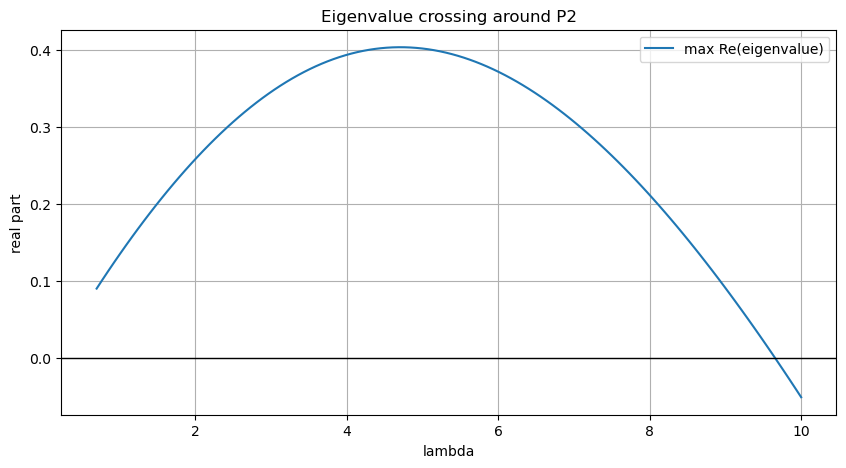

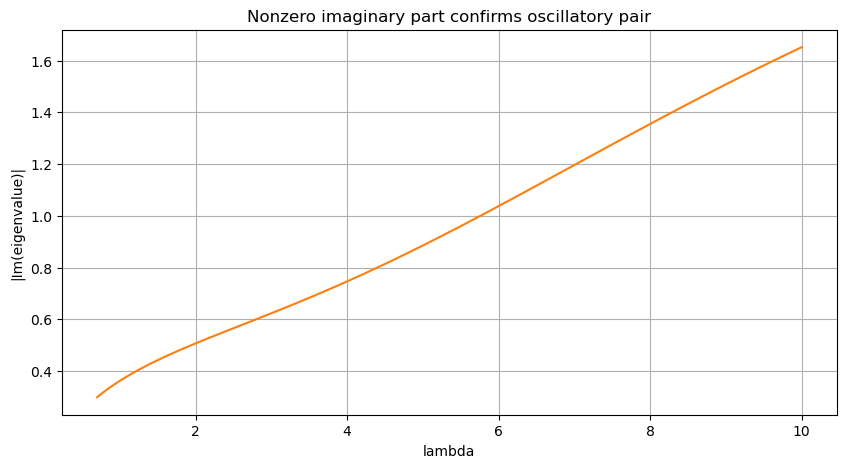

In [2]:
lams = np.linspace(0.7, 10.0, 120)
max_real = []
imag_at_max = []
for lam in lams:
    eig = np.linalg.eigvals(jacobian_P2(lam))
    pair = eig[np.argmax(eig.real)]
    max_real.append(pair.real)
    imag_at_max.append(abs(pair.imag))

plt.figure()
plt.plot(lams, max_real, label="max Re(eigenvalue)")
plt.axhline(0, color="black", lw=1)
plt.xlabel("lambda")
plt.ylabel("real part")
plt.title("Eigenvalue crossing around P2")
plt.legend()
plt.show()

plt.figure()
plt.plot(lams, imag_at_max, color="tab:orange")
plt.xlabel("lambda")
plt.ylabel("|Im(eigenvalue)|")
plt.title("Nonzero imaginary part confirms oscillatory pair")
plt.show()

## Experiment 2: time series before and after the crossing

The paper predicts periodic solutions near the Hopf threshold. We compare two representative parameter values.

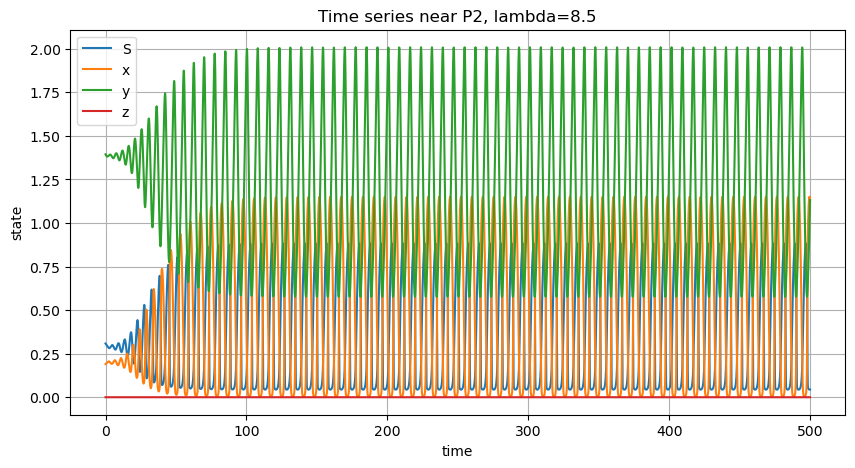

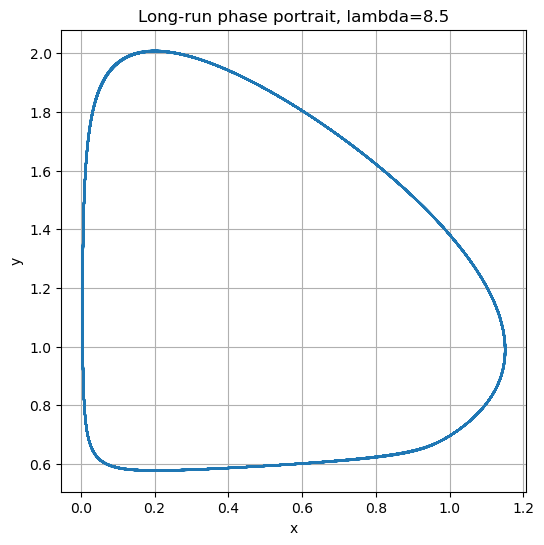

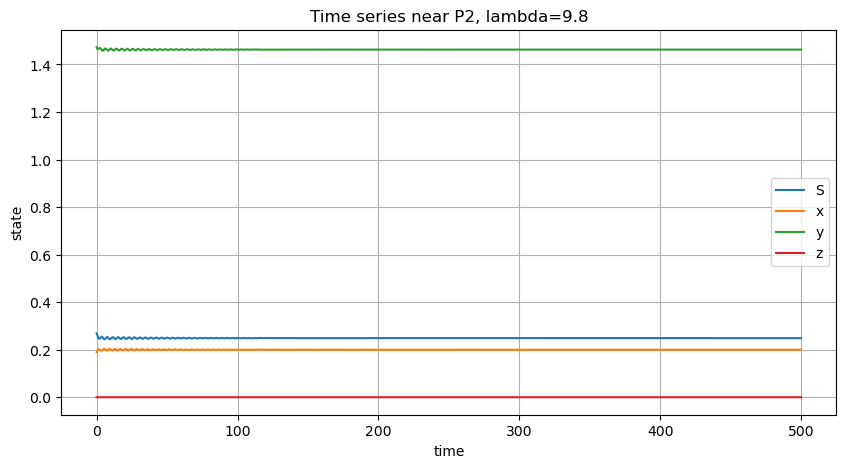

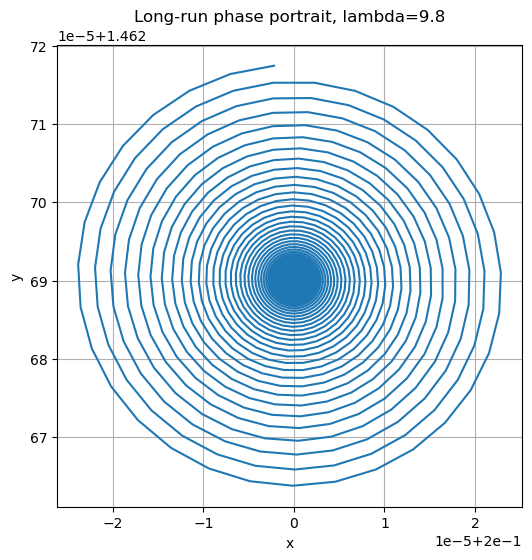

In [3]:
def simulate_lambda(lam, T=500):
    p = params(lam)
    U0 = P2(lam) + np.array([0.02, -0.01, 0.01, 0.0])
    U0 = np.maximum(U0, 1e-6)
    return solve_ivp(lambda t, U: rhs(t, U, p), (0, T), U0, dense_output=True, max_step=0.05, rtol=1e-8, atol=1e-10)

for lam in [8.5, 9.8]:
    sol = simulate_lambda(lam, T=500)
    t = np.linspace(0, 500, 4000)
    S, x, y, z = sol.sol(t)
    plt.figure(figsize=(10, 5))
    plt.plot(t, S, label="S")
    plt.plot(t, x, label="x")
    plt.plot(t, y, label="y")
    plt.plot(t, z, label="z")
    plt.xlabel("time")
    plt.ylabel("state")
    plt.title(f"Time series near P2, lambda={lam}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 6))
    keep = t > 250
    plt.plot(x[keep], y[keep])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Long-run phase portrait, lambda={lam}")
    plt.show()

## Experiment 3: numerical bifurcation diagram

Equivalent to the Hopf bifurcation discussion in Section 4. We discard transients and plot the long-run maxima/minima of `x(t)` against `lambda`.

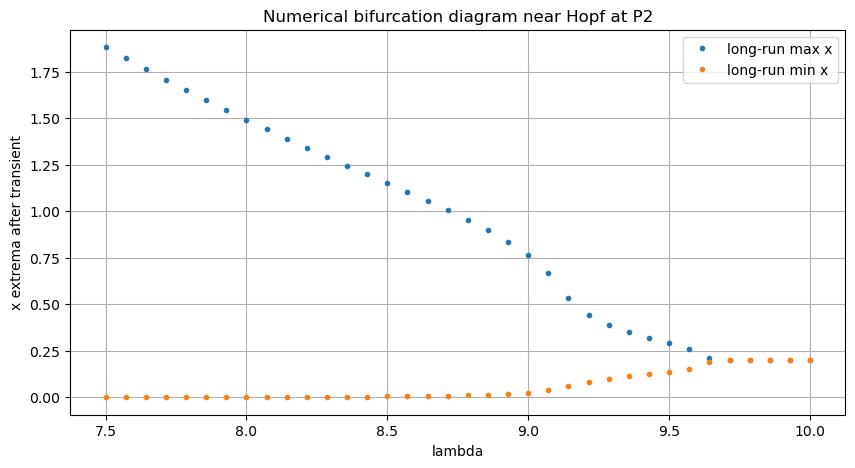

In [4]:
scan_lams = np.linspace(7.5, 10.0, 36)
x_max, x_min = [], []
for lam in scan_lams:
    sol = simulate_lambda(lam, T=450)
    t = np.linspace(250, 450, 2500)
    x = sol.sol(t)[1]
    x_max.append(x.max())
    x_min.append(x.min())

plt.figure()
plt.plot(scan_lams, x_max, ".", label="long-run max x")
plt.plot(scan_lams, x_min, ".", label="long-run min x")
plt.xlabel("lambda")
plt.ylabel("x extrema after transient")
plt.title("Numerical bifurcation diagram near Hopf at P2")
plt.legend()
plt.show()

## Note for reproducing Theorem 4.3 at P3

The same workflow applies to the full positive equilibrium `P3`: solve for `P3(lambda)`, compute the full 4x4 Jacobian, track complex eigenvalue crossings, then plot long-run extrema. The paper's Theorem 4.3 is theoretical; this notebook implements the same numerical protocol and uses `P2` because its crossing is easier to isolate with a compact parameter scan.